# Sentiment Analysis — EDA

Assumes columns: `review_text`, `star_rating`, `product_id`, `product_title`.
Update `DATA_PATH` and column names below if your dataset differs (keep them consistent with `COLUMN CONFIG` in the Day 1 script and `src/`).

In [1]:
import sys
sys.path.append('../..')

import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = '../../datasets/merged_reviews.csv'
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(59743, 7)


,product_id,product_title,brand,primaryCategories,review_text,review_title,star_rating
0,AVqkIhwDv8e3D1O-lebb,All-New Fire HD 8 Tablet,Amazon,NaN,This product so far has not disappointed. My c...,Kindle,5.0
1,AVqkIhwDv8e3D1O-lebb,All-New Fire HD 8 Tablet,Amazon,NaN,great for beginner or experienced person. Boug...,very fast,5.0
2,AVqkIhwDv8e3D1O-lebb,All-New Fire HD 8 Tablet,Amazon,NaN,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,5.0
3,AVqkIhwDv8e3D1O-lebb,All-New Fire HD 8 Tablet,Amazon,NaN,I've had my Fire HD 8 two weeks now and I love...,Good!!!,4.0
4,AVqkIhwDv8e3D1O-lebb,All-New Fire HD 8 Tablet,Amazon,NaN,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,5.0


## Missing values & basic stats

In [2]:
df.isna().sum()

product_id               0
product_title         6759
brand                    0
primaryCategories    34626
review_text              0
review_title            19
star_rating              0
dtype: int64

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,59743,89,AVphgVaX1cnluZ0-DR74,10966,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_title,52984,71,Fire Tablet,12351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,59743,7,Amazon,42687,NaN,NaN,NaN,NaN,NaN,NaN,NaN
primaryCategories,25117,10,Health & Beauty,10998,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_text,59743,46876,"A great Christmas gift, the kids love the gift...",6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_title,59724,25704,Five Stars,3332,NaN,NaN,NaN,NaN,NaN,NaN,NaN
star_rating,59743.0,NaN,NaN,NaN,4.548901,0.837035,1.0,4.0,5.0,5.0,5.0


## Star rating distribution

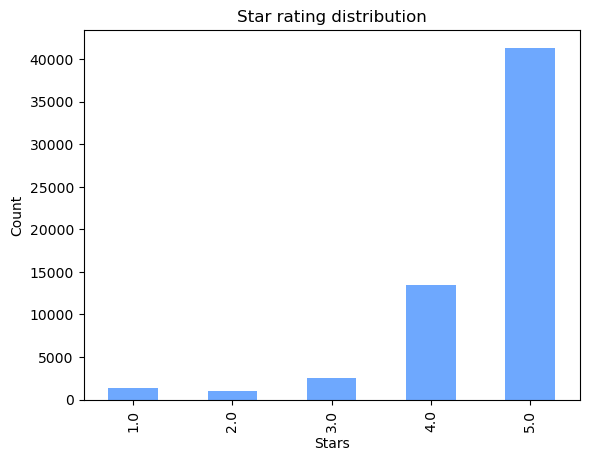

In [4]:
ax = df['star_rating'].value_counts().sort_index().plot(kind='bar', color='#6ea8fe')
ax.set_title('Star rating distribution')
ax.set_xlabel('Stars')
ax.set_ylabel('Count')
plt.show()

## Review length distribution
Long-tail check — helps decide truncation length for the transformer (max_length=512 tokens).

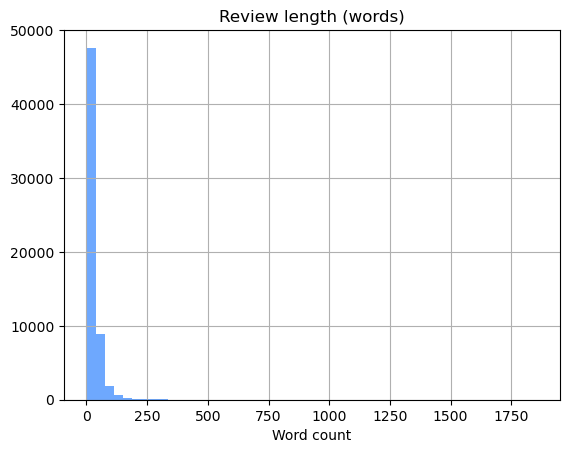

count    59743.000000
mean        28.586914
std         35.224018
min          1.000000
25%         12.000000
50%         19.000000
75%         34.000000
max       1858.000000
Name: review_length, dtype: float64

In [5]:
df['review_length'] = df['review_text'].astype(str).str.split().apply(len)
df['review_length'].hist(bins=50, color='#6ea8fe')
plt.title('Review length (words)')
plt.xlabel('Word count')
plt.show()
df['review_length'].describe()

## Map star ratings to sentiment classes and check class balance

sentiment
positive    54841
neutral      2588
negative     2314
Name: count, dtype: int64


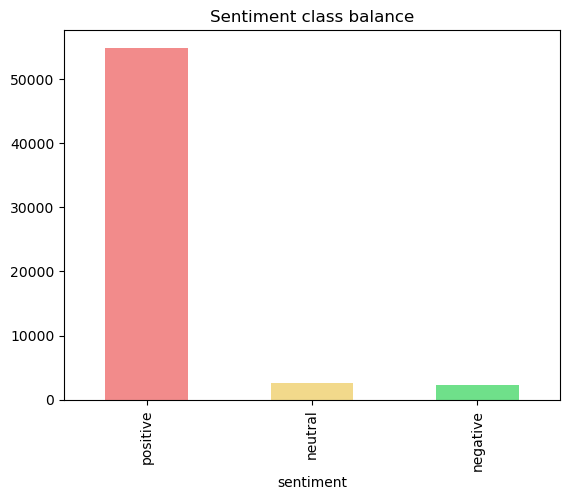

In [6]:
from src.sentiment.classifier import rating_to_sentiment

df['sentiment'] = df['star_rating'].apply(rating_to_sentiment)
counts = df['sentiment'].value_counts()
print(counts)
counts.plot(kind='bar', color=['#f28b8b', '#f2d98b', '#6fe08a'])
plt.title('Sentiment class balance')
plt.show()

**Note:** classes are likely imbalanced (few 3-star / neutral reviews is common in Amazon data). Keep this in mind when evaluating — accuracy alone can be misleading; check per-class precision/recall in `01_baseline.ipynb`.

## Sample reviews per class (sanity check the mapping makes sense)

In [7]:
for cls in ['negative', 'neutral', 'positive']:
    print(f'\n=== {cls.upper()} sample ===')
    for t in df[df.sentiment == cls]['review_text'].sample(2, random_state=1):
        print('-', str(t)[:200])


=== NEGATIVE sample ===
- My daughter got this for Christmas. Right out of the box it came on, but the screen was all white. Good price, but could never get it to work.
- I'm feeling like these are running out of performance faster than other batteries I've purchased.

=== NEUTRAL sample ===
- My toddler did not like this tablet. It was a bit slow for her. Instead, she preferred an iPad over the Kindle Kids version.
- It is an ok product. But the main reason for the purchase was because it was for a first time tablet owner. It is very cheap in price but without a google play store it kind of sucks. But like it says

=== POSITIVE sample ===
- My kids love theirs. No problem out of this tablet.
- This product is easy to set up, the interface is simple to learn and navigate. The remote has voiced activated commands for control of the TV box. The cost of this unit is much less than similar units


## Save a cleaned copy for downstream notebooks

In [8]:
clean = df.dropna(subset=['review_text', 'star_rating']).copy()
clean = clean[clean['review_text'].astype(str).str.strip().str.len() > 0]
clean = clean.drop_duplicates(subset=['review_text'])
clean.to_csv('../../datasets/clean_reviews.csv', index=False)
print(f'Saved {len(clean)} cleaned rows to datasets/clean_reviews.csv')

Saved 46876 cleaned rows to datasets/clean_reviews.csv
